# 02 - Làm sạch dữ liệu: Lucknow và Jaipur

**Đề tài:** Phân tích ô nhiễm không khí Ấn Độ theo thời gian (Nhóm 4 người). **Phần của mình:** Lucknow và Jaipur.
**Dữ liệu:** `data/raw/city_day.csv` (Kaggle, nguồn CPCB). Lucknow 2.009 ngày (1/1/2015 - 1/7/2020), Jaipur 1.114 ngày (14/6/2017 - 1/7/2020).

**Quy trình (bám theo W3, W4, W5 của giáo trình):**
1. Audit 6 chiều (EX3.1) -> 2. Mẫu hình và cơ chế thiếu (EX3.2) -> 3. So sánh chiến lược điền (EX3.3) -> 4. Xử lý thiếu, lưu `*_after_missing.csv`
5. So sánh phương pháp ngoại lai (EX4.1) -> 6. Điều tra điểm lớn nhất (EX4.2) -> 7. Xử lý, kiểm tra sau làm sạch (EX4.3), lưu `*_after_outliers.csv`
8. Biến đổi và xu hướng theo thời gian (W5) -> 9. Cleaning log (EX4.4)

**Cách chạy:** trong repo, mở file này từ thư mục `notebooks/` rồi Run all. Trên Colab: upload file zip của repo rồi Run all (ô đầu tự giải nén và tìm đường dẫn).

**Lưu ý:** các ô lập luận (EX3.1 đến EX4.2, xu hướng) là **bản nháp viết dựa trên output thật bên trên**. Hãy đọc và sửa lại bằng lời của bạn, vì thầy chấm theo lập luận.

In [1]:
# ===== 0. CẤU HÌNH & NẠP THƯ VIỆN =====
import os, sys, glob, zipfile, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 100)

def find_root():
    """Tìm thư mục gốc của repo (nơi có data/raw/city_day.csv và src/utils.py).
    Chạy trong repo (thư mục notebooks/) hoặc trên Colab sau khi upload zip đều được."""
    for attempt in range(2):
        cands = [Path.cwd(), *Path.cwd().parents, Path("/content/Air-Project-main"), Path("/content"),
                 *[p.parent.parent.parent for p in Path.cwd().glob("*/data/raw/city_day.csv")]]
        for p in cands:
            if (p / "data/raw/city_day.csv").exists() and (p / "src/utils.py").exists():
                return p
        for z in glob.glob("/content/*.zip") + glob.glob("*.zip"):   # Colab: tự giải nén zip đã upload
            with zipfile.ZipFile(z) as f:
                f.extractall("/content" if os.path.exists("/content") else ".")
    raise FileNotFoundError("Không thấy data/raw/city_day.csv và src/utils.py. "
                            "Hãy upload file zip của repo (Air-Project-...zip) lên Colab rồi chạy lại.")

ROOT = find_root()
sys.path.insert(0, str(ROOT / "src"))
from utils import POLLUTANT_COLS, audit, load_and_split_city, diagnose_missing, flag_flatline_zeros   # code chung của nhóm
from gap_utils import (gap_runs, interpolate_short_gaps, outlier_flags, contextual_ratio, aqi_bucket)   # code bổ sung (Lucknow + Jaipur)

RAW = ROOT / "data/raw/city_day.csv"
INTERIM = ROOT / "data/interim"; REPORTS = ROOT / "reports"; FIG = REPORTS / "figures"
for p in (INTERIM, REPORTS, FIG): p.mkdir(parents=True, exist_ok=True)

CITIES   = ["Lucknow", "Jaipur"]
MAX_GAP  = 14     # chỉ nội suy khoảng thiếu <= 14 ngày (giống ngưỡng mặc định trong utils.py của nhóm)
FLAT_RUN = 3      # chuỗi số 0 liên tiếp >= 3 ngày -> coi là cảm biến treo (giống utils.py của nhóm)
CTX_THR  = 2.5    # điểm cao gấp >= 2,5 lần trung vị 15 ngày quanh nó -> ngoại lai theo ngữ cảnh (quyết định của mình)
WINTER   = {10, 11, 12, 1, 2}   # mùa ô nhiễm cao ở miền bắc Ấn Độ
LOG = []
def log(step, city, col, issue, action, n, reason):
    LOG.append(dict(step=step, city=city, column=col, issue=issue, action=action, n_affected=n, reason=reason))

print("Thư mục gốc:", ROOT)
raw = {c: load_and_split_city(c, str(RAW)) for c in CITIES}
for c in CITIES: print(c, raw[c].shape)

Thư mục gốc: /home/claude/Air-Project-main
Lucknow (2009, 16)
Jaipur (1114, 16)


## 1. Kiểm tra chất lượng dữ liệu (EX3.1) - 6 chiều

In [2]:
def audit6(d):
    cols = POLLUTANT_COLS + ["AQI"]
    pct = d[cols].isna().mean() * 100
    empty = list(pct[pct == 100].index)
    zeros = (d[POLLUTANT_COLS] == 0).sum(); zeros = zeros[zeros > 0].to_dict()
    exp = aqi_bucket(d["AQI"]); both = d["AQI"].notna() & d["AQI_Bucket"].notna()
    has_pm10 = d["PM10"].notna().any()
    return pd.Series({
        "Phạm vi thời gian": f"{d.Date.min().date()} -> {d.Date.max().date()}",
        "Số dòng / số ngày lịch": f"{len(d)} / {(d.Date.max() - d.Date.min()).days + 1}",
        "Completeness: % thiếu TB (13 cột số)": round(pct.mean(), 1),
        "Completeness: cột thiếu 100%": ", ".join(empty) or "không có",
        "Completeness: % thiếu TB (bỏ cột rỗng)": round(pct.drop(empty).mean(), 1),
        "Uniqueness: ngày trùng": int(d.Date.duplicated().sum()),
        "Uniqueness: dòng trùng hoàn toàn": int(d.duplicated().sum()),
        "Validity: giá trị âm": int((d[cols] < 0).sum().sum()),
        "Validity: AQI > 500 (thang tối đa)": int((d["AQI"] > 500).sum()),
        "Validity: số 0 nghi ngờ (cột: số ngày)": str(zeros) if zeros else "không có",
        "Consistency: AQI_Bucket lệch AQI": int((exp[both] != d.loc[both, "AQI_Bucket"]).sum()),
        "Consistency: PM2.5 > PM10": int((d["PM2.5"] > d["PM10"]).sum()) if has_pm10 else "không kiểm tra được (PM10 rỗng)",
        "Timeliness: ngày cuối cùng": str(d.Date.max().date()),
    })

audit_tbl = pd.DataFrame({c: audit6(raw[c]) for c in CITIES})
display(audit_tbl)
for c in CITIES:
    print(f"\n=== {c}: audit từng cột (utils.audit) ===")
    display(audit(raw[c]).sort_values("pct_missing", ascending=False))

,Lucknow,Jaipur
Phạm vi thời gian,2015-01-01 -> 2020-07-01,2017-06-14 -> 2020-07-01
Số dòng / số ngày lịch,2009 / 2009,1114 / 1114
Completeness: % thiếu TB (13 cột số),22.8,9.6
Completeness: cột thiếu 100%,"PM10, Xylene",Xylene
Completeness: % thiếu TB (bỏ cột rỗng),8.8,2.1
Uniqueness: ngày trùng,0,0
Uniqueness: dòng trùng hoàn toàn,0,0
Validity: giá trị âm,0,0
Validity: AQI > 500 (thang tối đa),15,0
Validity: số 0 nghi ngờ (cột: số ngày),"{'CO': 5, 'Benzene': 79, 'Toluene': 74}","{'CO': 61, 'Benzene': 86, 'Toluene': 12}"



=== Lucknow: audit từng cột (utils.audit) ===


,dtype,n_missing,pct_missing,n_unique
PM10,float64,2009,100.0,0
Xylene,float64,2009,100.0,0
NH3,float64,1004,50.0,853
NOx,float64,324,16.1,1063
Toluene,float64,136,6.8,824
AQI_Bucket,str,116,5.8,6
AQI,float64,116,5.8,423
PM2.5,float64,102,5.1,1812
Benzene,float64,99,4.9,552
SO2,float64,64,3.2,970



=== Jaipur: audit từng cột (utils.audit) ===


,dtype,n_missing,pct_missing,n_unique
Xylene,float64,1114,100.0,0
NOx,float64,112,10.1,913
Toluene,float64,23,2.1,759
Benzene,float64,22,2.0,386
AQI,float64,20,1.8,221
AQI_Bucket,str,20,1.8,6
NO,float64,16,1.4,865
PM10,float64,14,1.3,1068
NO2,float64,14,1.3,972
O3,float64,15,1.3,1021


### EX3.1 - Chấm điểm 6 chiều chất lượng (1 = rất kém, 5 = rất tốt)

| Chiều | Lucknow | Bằng chứng | Jaipur | Bằng chứng |
|---|---|---|---|---|
| Completeness | 2 | Thiếu TB 22,8% (PM10 và Xylene rỗng 100%; NH3 thiếu 50%). Bỏ 2 cột rỗng thì còn 8,8% | 4 | Thiếu TB 9,6% chỉ vì Xylene rỗng; bỏ Xylene còn 2,1%. NOx thiếu 10,1% (một khối 112 ngày đầu chuỗi) |
| Accuracy | 3 | Không đối chiếu được nguồn ngoài; 3 ngày 20-22/3/2015 nghi lỗi cảm biến | 3 | Không đối chiếu được nguồn ngoài; ngày 6/2/2018 PM2.5 (311) gấp 2,5 lần PM10 (123) |
| Consistency | 4 | AQI_Bucket khớp AQI 100%; không kiểm tra được PM2.5 <= PM10 vì thiếu PM10 | 3 | AQI_Bucket khớp 100%, nhưng có 13 ngày PM2.5 > PM10 (vô lý vì PM10 gồm cả PM2.5) |
| Validity | 3 | Không có giá trị âm; 15 ngày AQI > 500, trong đó 3 ngày nghi lỗi; số 0 kéo dài ở Benzene (79) và Toluene (74) | 3 | Không có giá trị âm, không có AQI > 500; số 0 kéo dài ở CO (61 ngày, 51 ngày rơi vào 12/2017-1/2018) và Benzene (86 ngày, 6-10/2017) |
| Uniqueness | 5 | 0 ngày trùng, 0 dòng trùng | 5 | 0 ngày trùng, 0 dòng trùng |
| Timeliness | 2 | Dữ liệu dừng ở 1/7/2020, nhưng đủ 2.009/2.009 ngày | 2 | Dừng ở 1/7/2020; chỉ có 3 năm 1 tháng, đủ 1.114/1.114 ngày |

Điểm là đánh giá của mình. Chỗ chắc chắn là các con số ở cột Bằng chứng; điểm 3 ở Accuracy là do **không có cách kiểm chứng**, không phải do đã thấy sai.

## 2. Dữ liệu thiếu: mẫu hình và cơ chế (EX3.2)


=== Lucknow: khoảng thiếu (ngày liên tiếp) ===


,pct_missing,n_gaps,longest_gap,gaps_over_14,pct_missing_in_long_gaps
col,,,,,
PM2.5,5.1,7,78,1,76.0
PM10,100.0,1,2009,1,100.0
NO,1.2,6,13,0,0.0
NO2,1.2,6,13,0,0.0
NOx,16.1,14,104,4,85.0
NH3,50.0,4,999,1,100.0
CO,1.4,12,13,0,0.0
SO2,3.2,14,13,0,0.0
O3,1.3,8,13,0,0.0


--- Lucknow: % thiếu theo năm ---


Date,2015,2016,2017,2018,2019,2020
PM2.5,22,6,1,0,0,0
PM10,100,100,100,100,100,100
NO,0,6,1,0,0,0
NO2,0,6,1,0,0,0
NOx,0,25,63,0,0,0
NH3,100,100,73,0,1,2
CO,0,7,1,0,0,0
SO2,11,6,1,0,0,0
O3,0,6,1,1,0,0
Benzene,15,11,2,0,0,0



=== Jaipur: khoảng thiếu (ngày liên tiếp) ===


,pct_missing,n_gaps,longest_gap,gaps_over_14,pct_missing_in_long_gaps
col,,,,,
PM2.5,1.1,4,5,0,0.0
PM10,1.3,5,5,0,0.0
NO,1.4,6,5,0,0.0
NO2,1.3,6,5,0,0.0
NOx,10.1,1,112,1,100.0
NH3,1.3,6,5,0,0.0
CO,0.6,2,5,0,0.0
SO2,1.1,4,5,0,0.0
O3,1.3,6,5,0,0.0


--- Jaipur: % thiếu theo năm ---


Date,2017,2018,2019,2020
PM2.5,6,0,0,0
PM10,7,0,0,0
NO,8,0,0,0
NO2,7,0,0,0
NOx,56,0,0,0
NH3,7,0,0,0
CO,3,0,0,0
SO2,6,0,0,0
O3,7,0,0,0
Benzene,11,0,0,0


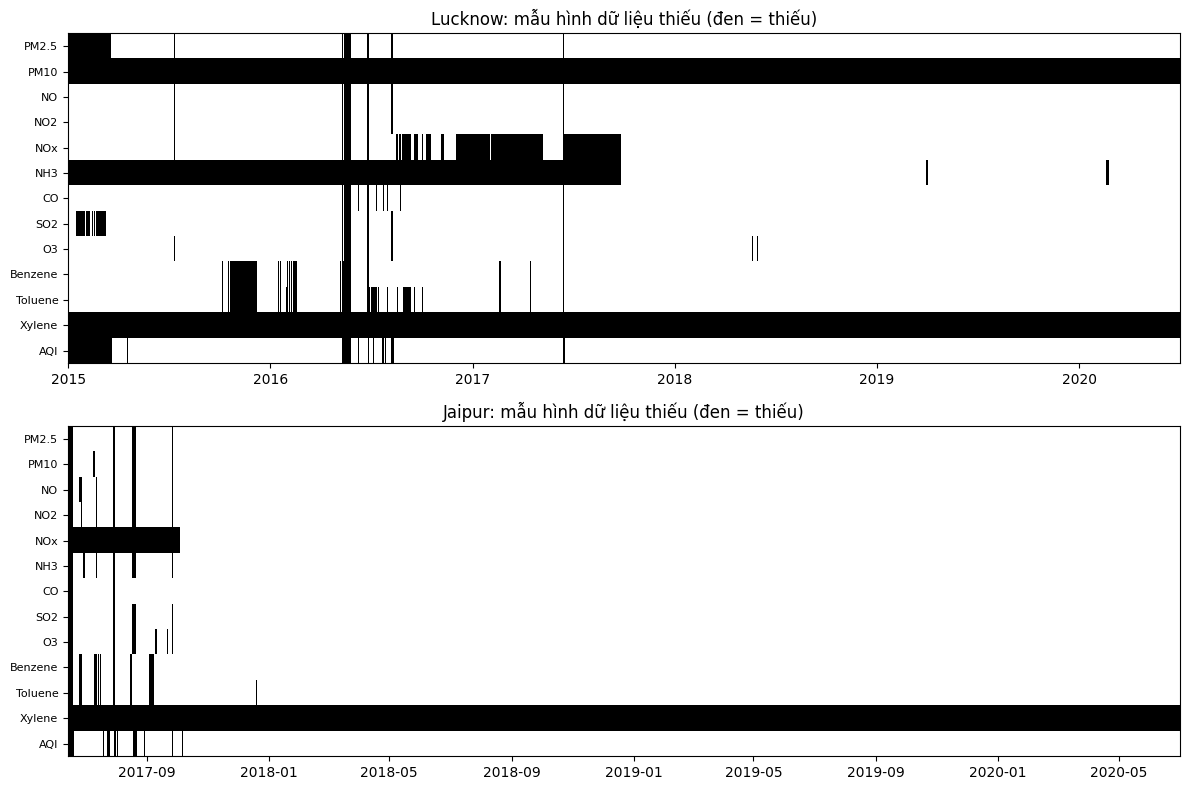

In [3]:
def gap_table(d, cols):
    s = d.set_index("Date"); rows = []
    for c in cols:
        if s[c].isna().all():
            rows.append(dict(col=c, pct_missing=100.0, n_gaps=1, longest_gap=len(s), gaps_over_14=1, pct_missing_in_long_gaps=100.0)); continue
        r = gap_runs(s[c]); tot = int(s[c].isna().sum()); long_ = r[r > MAX_GAP]
        rows.append(dict(col=c, pct_missing=round(tot / len(s) * 100, 1), n_gaps=len(r),
                         longest_gap=int(r.max()) if len(r) else 0, gaps_over_14=len(long_),
                         pct_missing_in_long_gaps=round(long_.sum() / tot * 100) if tot else 0))
    return pd.DataFrame(rows).set_index("col")

for c in CITIES:
    print(f"\n=== {c}: khoảng thiếu (ngày liên tiếp) ===")
    display(gap_table(raw[c], POLLUTANT_COLS + ["AQI"]))
    print(f"--- {c}: % thiếu theo năm ---")
    s = raw[c].set_index("Date")
    display((s[POLLUTANT_COLS + ["AQI"]].isna().groupby(s.index.year).mean() * 100).round(0).astype(int).T)

fig, axes = plt.subplots(len(CITIES), 1, figsize=(12, 8))
for ax, c in zip(axes, CITIES):
    s = raw[c].set_index("Date")[POLLUTANT_COLS + ["AQI"]]
    ax.imshow(s.isna().T.values, aspect="auto", interpolation="nearest", cmap="Greys",
              extent=[mdates.date2num(s.index.min()), mdates.date2num(s.index.max()), len(s.columns), 0])
    ax.xaxis_date(); ax.set_yticks(np.arange(len(s.columns)) + 0.5); ax.set_yticklabels(s.columns, fontsize=8)
    ax.set_title(f"{c}: mẫu hình dữ liệu thiếu (đen = thiếu)")
plt.tight_layout(); plt.savefig(FIG / "missing_pattern_lucknow_jaipur.png", dpi=130); plt.show()

### EX3.2 - Cơ chế thiếu và cách xử lý

Từ bảng khoảng thiếu, bảng % thiếu theo năm và hình mẫu hình thiếu ở trên:

**Lucknow**

| Cột | Mẫu hình thiếu | Cơ chế | Xử lý | Lý do |
|---|---|---|---|---|
| PM10, Xylene | Thiếu 100% mọi năm | Trạm không đo hai chất này | Bỏ cột | Không có dữ liệu thật để điền hay phân tích |
| NH3 | 100% năm 2015-2016, 73% năm 2017, ~0% từ 2018; **một khoảng trống liên tục 999 ngày** | Phụ thuộc thời gian (thiết bị chưa hoạt động), gần với MAR | Giữ NaN, chỉ dùng NH3 từ cuối 2017 | Điền 999 ngày là bịa số; còn 49,7% thiếu sau xử lý |
| NOx | 25% năm 2016, 63% năm 2017, 0% các năm khác; 4 khoảng > 14 ngày chiếm 85% ngày thiếu (dài nhất 104) | Phụ thuộc thời gian (MAR) | Nội suy khoảng <= 14 ngày, còn lại NaN | Chuỗi thời gian liên tục, khoảng ngắn nội suy an toàn |
| PM2.5, AQI | 22% năm 2015 rồi <= 9%, ~0% từ 2018; **khối 78-79 ngày ở đầu chuỗi** (1/1 - 19/3/2015) | Trạm mới bắt đầu chạy (MAR). AQI thiếu gần trùng PM2.5 vì AQI tính từ PM | PM2.5 nội suy khoảng ngắn; **AQI không điền** (theo quy ước nhóm: AQI là biến kết quả) | Khối đầu chuỗi không có giá trị hai bên để nội suy |
| NO, NO2, CO, SO2, O3 | Khoảng dài nhất 13 ngày, rải rác. Hình cho thấy một vạch dọc cắt qua hầu hết các cột quanh giữa 2016 | Cả trạm ngừng cùng lúc (mất điện hay hỏng chung) | Nội suy toàn bộ, còn 0% | Mọi khoảng <= 14 ngày |
| Benzene, Toluene | Khoảng dài nhất 49 ngày, cộng thêm 75 và 72 ngày số 0 liên tục | Số 0 là "sentinel": cảm biến treo (W3) | Số 0 liên tục >= 3 ngày -> NaN, rồi nội suy khoảng ngắn | Nồng độ thật gần như không bao giờ đứng đúng 0 nhiều ngày |

**Jaipur**

| Cột | Mẫu hình thiếu | Cơ chế | Xử lý | Lý do |
|---|---|---|---|---|
| Xylene | 100% | Trạm không đo | Bỏ cột | Như trên |
| NOx | **Một khối 112 ngày ở đầu chuỗi** (56% của năm 2017), 0% sau đó | Phụ thuộc thời gian (thiết bị chưa chạy), MAR | Giữ NaN | Khoảng dài, không có giá trị trước để nội suy |
| PM2.5, PM10, NO, NO2, NH3, SO2, O3, Toluene | Khoảng dài nhất 5 ngày, rải rác, 1-2% mỗi cột | Ngắn, gần MCAR | Nội suy toàn bộ; chỉ còn 0,4% là 5 ngày đầu chuỗi (không nội suy ra ngoài) | Khoảng ngắn |
| CO, Benzene | Số 0 liên tục: CO 60 ngày (tập trung 12/2017-1/2018), Benzene 80 ngày (6-10/2017) | Sentinel: cảm biến treo | Số 0 liên tục -> NaN, rồi nội suy khoảng ngắn. Các khối dài hơn 14 ngày **giữ NaN**; CO còn 5,5%, Benzene còn 4,8% | Điền khối dài là bịa số |
| AQI | 1,8%, khoảng dài nhất 6 ngày | Ngắn | Không điền (quy ước nhóm) | AQI là biến kết quả |

Mình chỉ kết luận được "phụ thuộc thời gian" từ dữ liệu. Để chứng minh MCAR hay MNAR cần thêm thông tin từ CPCB về lý do trạm ngừng, dữ liệu này không có.

## 3. So sánh 4 chiến lược điền thiếu trên PM2.5 (EX3.3)

=== Lucknow: PM2.5 gốc thiếu 102/2009 ngày ===


,n_co_gia_tri,con_thieu,mean,median,std
chien_luoc,,,,,
A. Bỏ dòng thiếu,1907,0,109.7,86.1,79.8
B. Median toàn cục,2009,0,108.5,86.1,77.9
C. Median theo tháng,2009,0,110.3,88.9,78.4
D. Nội suy khoảng <= 14 ngày,1931,78,109.0,85.4,79.6


=== Jaipur: PM2.5 gốc thiếu 12/1114 ngày ===


,n_co_gia_tri,con_thieu,mean,median,std
chien_luoc,,,,,
A. Bỏ dòng thiếu,1102,0,54.5,49.8,26.6
B. Median toàn cục,1114,0,54.4,49.8,26.4
C. Median theo tháng,1114,0,54.3,49.5,26.5
D. Nội suy khoảng <= 14 ngày,1109,5,54.4,49.6,26.5


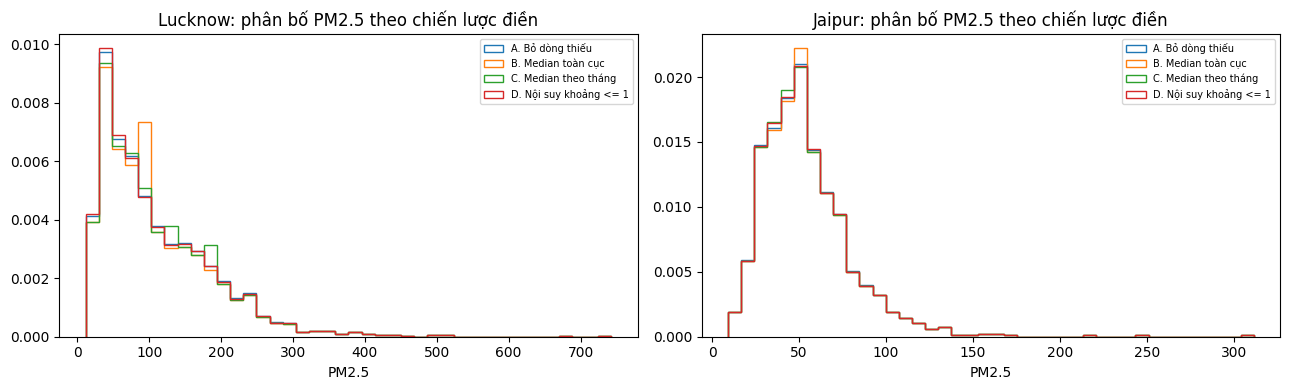

In [4]:
def compare_fill(d, col="PM2.5"):
    s = d.set_index("Date")[col]
    strat = {
        "A. Bỏ dòng thiếu":               s.dropna(),
        "B. Median toàn cục":             s.fillna(s.median()),
        "C. Median theo tháng":           s.fillna(s.groupby(s.index.month).transform("median")),
        f"D. Nội suy khoảng <= {MAX_GAP} ngày": interpolate_short_gaps(s, MAX_GAP),
    }
    rows = [dict(chien_luoc=k, n_co_gia_tri=int(v.notna().sum()), con_thieu=int(v.isna().sum()),
                 mean=round(v.mean(), 1), median=round(v.median(), 1), std=round(v.std(), 1)) for k, v in strat.items()]
    return pd.DataFrame(rows).set_index("chien_luoc"), strat

fig, axes = plt.subplots(1, len(CITIES), figsize=(13, 4))
for ax, c in zip(axes, CITIES):
    tbl, strat = compare_fill(raw[c])
    print(f"=== {c}: PM2.5 gốc thiếu {int(raw[c]['PM2.5'].isna().sum())}/{len(raw[c])} ngày ==="); display(tbl)
    for k, v in strat.items(): ax.hist(v.dropna(), bins=40, histtype="step", density=True, label=k[:2] + k[2:22])
    ax.set_title(f"{c}: phân bố PM2.5 theo chiến lược điền"); ax.set_xlabel("PM2.5"); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIG / "fill_strategies_lucknow_jaipur.png", dpi=130); plt.show()

### EX3.3 - So sánh 4 chiến lược điền trên PM2.5

| | Lucknow n | mean | std | Jaipur n | mean | std |
|---|---|---|---|---|---|---|
| A. Bỏ dòng thiếu | 1907 | 109,7 | 79,8 | 1102 | 54,5 | 26,6 |
| B. Median toàn cục | 2009 | 108,5 | 77,9 | 1114 | 54,4 | 26,4 |
| C. Median theo tháng | 2009 | 110,3 | 78,4 | 1114 | 54,3 | 26,5 |
| D. Nội suy khoảng <= 14 ngày | 1931 (thiếu 78) | 109,0 | 79,6 | 1109 (thiếu 5) | 54,4 | 26,5 |

**Nhận xét.**
- **Lucknow:** B làm độ lệch chuẩn giảm từ 79,8 xuống 77,9 và tạo đỉnh nhọn tại median 86,1 trên biểu đồ phân bố, đúng cảnh báo "điền bằng mean/median làm méo phân bố". C nhích mean lên 110,3; có thể do các ngày thiếu tập trung ở đầu năm 2015 (mùa ô nhiễm cao) nên median theo tháng cao hơn median toàn cục (đây là suy luận, chưa kiểm chứng riêng). D gần như giữ nguyên phân bố (std 79,6) nhưng **chỉ điền được 24 trong 102 ngày thiếu**, 78 ngày còn lại là khối đầu chuỗi.
- **Jaipur:** PM2.5 chỉ thiếu 1,1% nên cả bốn cách gần như giống hệt nhau (mean 54,3 - 54,5). Chọn cách nào cũng ít ảnh hưởng.
- **Chọn D cho cả hai thành phố.** Lý do: ngày liền kề của chuỗi thời gian rất giống nhau (tự tương quan), median toàn cục hay theo tháng bỏ qua điều đó. Đổi lại D **không** điền khối dài; mình chấp nhận để NaN thay vì bịa số cho 78 ngày.
- Khác biệt giữa các mean chỉ ~1 đơn vị nên không nên nói "cách này chính xác hơn"; điểm phân biệt thật sự là độ lệch chuẩn và đỉnh nhọn ở B.

## 4. Áp dụng xử lý thiếu và lưu `*_after_missing.csv`

Cùng quy tắc và cùng định dạng file với `delhi_after_missing.csv` của bạn Tuấn (flatline >= 3 ngày -> NaN, giữ cột `*_was_missing`, không tự điền AQI), **chỉ khác một điểm**: dùng hàm nội suy đã sửa lỗi ở `src/gap_utils.py` (xem ghi chú ở cuối notebook).

In [5]:
def clean_missing(d, city):
    d = d.sort_values("Date").reset_index(drop=True)
    d, flat = flag_flatline_zeros(d, cols=POLLUTANT_COLS, min_run=FLAT_RUN)          # 1) số 0 liên tục -> NaN
    flag_cols = [c for c in POLLUTANT_COLS + ["AQI"] if c in d.columns]
    for c in flag_cols: d[f"{c}_was_missing"] = d[c].isna()                             # 2) giữ vết thiếu gốc
    drop_cols = [c for c in POLLUTANT_COLS if d[c].isna().all()]                        # 3) bỏ cột rỗng hoàn toàn
    d = d.drop(columns=drop_cols)
    d = d.set_index("Date")
    n_before = {c: int(d[c].isna().sum()) for c in POLLUTANT_COLS if c in d.columns}
    for c in [x for x in POLLUTANT_COLS if x in d.columns]:                              # 4) nội suy khoảng ngắn
        d[c] = interpolate_short_gaps(d[c], MAX_GAP)
    n_filled = {c: n_before[c] - int(d[c].isna().sum()) for c in n_before}
    d = d.reset_index()
    for c, n in flat.items():
        log("3.x flatline", city, c, "chuỗi số 0 liên tiếp >= 3 ngày (cảm biến treo, sentinel)", "đổi thành NaN", n,
            "nồng độ khí thật hiếm khi đứng ở đúng 0 nhiều ngày liền")
    for c in drop_cols:
        log("3.2 missing", city, c, "thiếu 100% mọi năm", "bỏ cột", len(d), "không có dữ liệu thật để phân tích hay nội suy")
    for c, n in n_filled.items():
        if n: log("3.3 impute", city, c, f"thiếu {n_before[c]} ngày (sau flatline)", f"nội suy theo thời gian, khoảng <= {MAX_GAP} ngày", n,
                  "chuỗi thời gian liên tục; khoảng dài hơn giữ NaN để không bịa số")
    return d, flat, drop_cols, n_filled

clean, summary = {}, []
for c in CITIES:
    clean[c], flat, dropped, filled = clean_missing(raw[c], c)
    print(f"\n=== {c} ===")
    print("Số 0 flatline -> NaN:", flat); print("Cột bị bỏ:", dropped); print("Số ngày đã nội suy:", {k: v for k, v in filled.items() if v})
    cols = [x for x in POLLUTANT_COLS + ["AQI"] if x in clean[c].columns]
    summary.append(pd.DataFrame({"truoc_%": (raw[c][cols].isna().mean() * 100).round(1),
                                 "sau_%": (clean[c][cols].isna().mean() * 100).round(1)}).assign(city=c))
    clean[c].to_csv(INTERIM / f"{c.lower()}_after_missing.csv", index=False)
display(pd.concat(summary).set_index("city", append=True).swaplevel().sort_index(level=0, sort_remaining=False))
print("\nĐã lưu:", [f"{c.lower()}_after_missing.csv" for c in CITIES])


=== Lucknow ===
Số 0 flatline -> NaN: {'CO': 5, 'Benzene': 75, 'Toluene': 72}
Cột bị bỏ: ['PM10', 'Xylene']
Số ngày đã nội suy: {'PM2.5': 24, 'NO': 24, 'NO2': 24, 'NOx': 48, 'NH3': 5, 'CO': 33, 'SO2': 64, 'O3': 27, 'Benzene': 45, 'Toluene': 64}

=== Jaipur ===
Số 0 flatline -> NaN: {'CO': 60, 'Benzene': 80, 'Toluene': 4}
Cột bị bỏ: ['Xylene']
Số ngày đã nội suy: {'PM2.5': 7, 'PM10': 9, 'NO': 11, 'NO2': 9, 'NH3': 10, 'CO': 6, 'SO2': 7, 'O3': 10, 'Benzene': 49, 'Toluene': 22}


truoc_%  sau_%
city                           
Jaipur  PM2.5        1.1    0.4
        PM10         1.3    0.4
        NO           1.4    0.4
        NO2          1.3    0.4
        NOx         10.1   10.1
        NH3          1.3    0.4
        CO           0.6    5.5
        SO2          1.1    0.4
        O3           1.3    0.4
        Benzene      2.0    4.8
        Toluene      2.1    0.4
        AQI          1.8    1.8
Lucknow PM2.5        5.1    3.9
        NO           1.2    0.0
        NO2          1.2    0.0
        NOx         16.1   13.7
        NH3         50.0   49.7
        CO           1.4    0.0
        SO2          3.2    0.0
        O3           1.3    0.0
        Benzene      4.9    6.4
        Toluene      6.8    7.2
        AQI          5.8    5.8


Đã lưu: ['lucknow_after_missing.csv', 'jaipur_after_missing.csv']


## 5. Ngoại lai: so sánh các phương pháp (EX4.1)

n  Z_score  ModZ  IQR  Ngu_canh
city    col                                      
Lucknow PM2.5  1931       24    38   39        20
        NO2    2009       16    13   23         7
        CO     2009       73   189  189        62
        SO2    2009       61   109  126         8
        AQI    1893        6     0    2         7
Jaipur  PM2.5  1109       13    18   33         3
        PM10   1109       10     9   21        12
        NO2    1109       16    16   29         1
        CO     1053       16    32   64         3
        SO2    1109       13    18   48         0
        AQI    1094       12    15   39         3

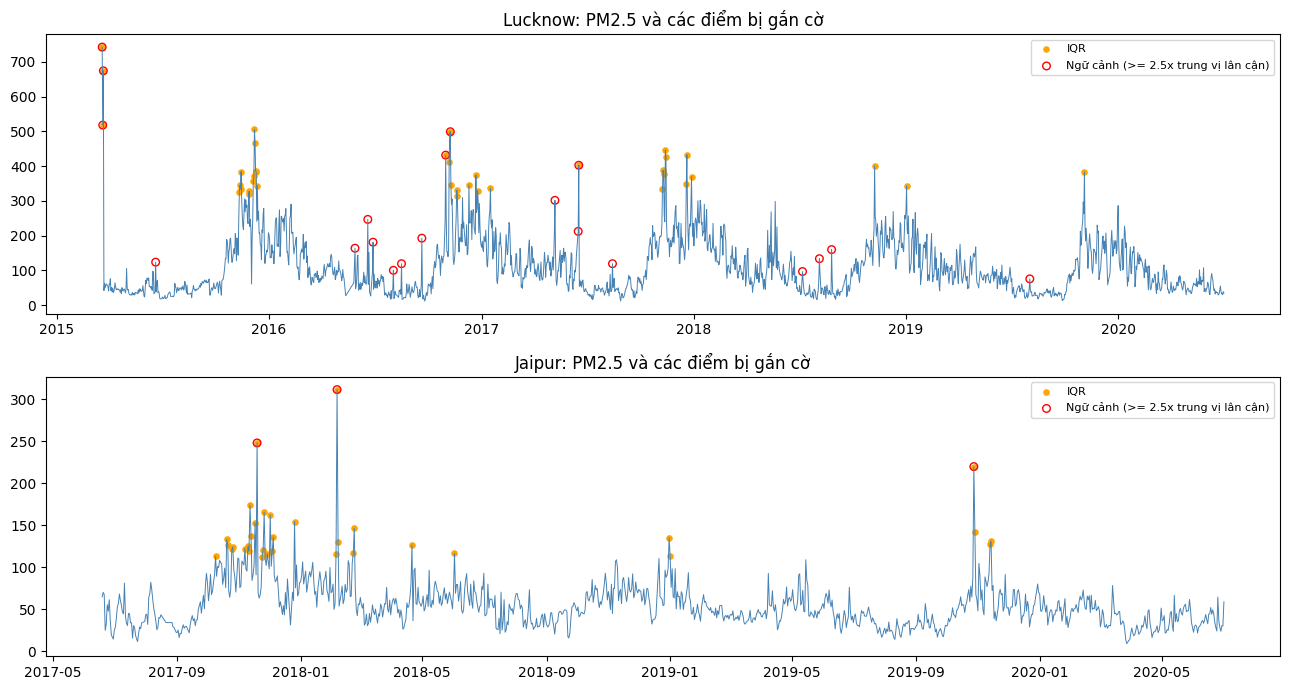

In [6]:
OUT_COLS = ["PM2.5", "PM10", "NO2", "CO", "SO2", "AQI"]
rows = []
for c in CITIES:
    s = clean[c].set_index("Date")
    for col in [x for x in OUT_COLS if x in s.columns]:
        f = outlier_flags(s[col]); ctx = contextual_ratio(s[col]) >= CTX_THR
        rows.append(dict(city=c, col=col, n=int(s[col].notna().sum()), Z_score=int(f.z.sum()), ModZ=int(f.modz.sum()),
                         IQR=int(f.iqr.sum()), Ngu_canh=int(ctx.sum())))
cmp_tbl = pd.DataFrame(rows).set_index(["city", "col"]); display(cmp_tbl)

fig, axes = plt.subplots(len(CITIES), 1, figsize=(13, 7), sharex=False)
for ax, c in zip(axes, CITIES):
    s = clean[c].set_index("Date")["PM2.5"]; f = outlier_flags(s); ctx = contextual_ratio(s) >= CTX_THR
    ax.plot(s.index, s.values, lw=0.7, color="steelblue")
    ax.scatter(s.index[f.iqr], s[f.iqr], s=14, color="orange", label="IQR")
    ax.scatter(s.index[ctx], s[ctx], s=30, facecolors="none", edgecolors="red", label=f"Ngữ cảnh (>= {CTX_THR}x trung vị lân cận)")
    ax.set_title(f"{c}: PM2.5 và các điểm bị gắn cờ"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "outliers_pm25_lucknow_jaipur.png", dpi=130); plt.show()

### EX4.1 - So sánh các phương pháp ngoại lai

Bốn phương pháp: Z-score (|z| > 3), Modified Z (MAD, > 3,5), IQR (1,5 x IQR), và **ngữ cảnh** (cao gấp >= 2,5 lần trung vị 15 ngày quanh nó).

- **Lucknow PM2.5:** Z 24, ModZ 38, IQR 39, ngữ cảnh 20 (trên 1.931 ngày). Z gắn ít nhất vì các đỉnh cực lớn (742...) làm độ lệch chuẩn phình ra, che các điểm nhỏ hơn (hiện tượng masking); ModZ và IQR dùng trung vị/tứ phân vị nên bền hơn.
- **Lucknow AQI:** Z 6, **ModZ 0**, IQR 2, ngữ cảnh 7. AQI có mùa rất mạnh (trung vị mùa đông 339, mùa gió mùa 100) nên các phương pháp toàn cục không thấy được đỉnh trái mùa tháng 3/2015 (AQI ~600-700); chỉ phương pháp ngữ cảnh bắt được (cao gấp 5-6 lần lân cận).
- **Jaipur:** IQR gắn nhiều hơn hẳn Z (PM2.5: 33 so với 13; AQI: 39 so với 12; CO: 64 so với 16). Phân bố lệch phải nên IQR gắn cả đuôi phải, tức mùa đông và bụi; nhiều điểm trong số đó là hiện tượng thật, không phải lỗi. Ngữ cảnh chỉ gắn 3 điểm PM2.5, dễ điều tra từng điểm.
- **CO, SO2 ở Lucknow:** ModZ và IQR gắn CO 189 ngày (~9%) và SO2 109-126 ngày (~5-6%) trên 2.009 ngày, quá nhiều để là lỗi, nhiều khả năng do phân bố nặng đuôi hoặc mức đo thay đổi theo giai đoạn.
- **Quyết định:** không xóa ngoại lai bằng phương pháp toàn cục. Chỉ **gắn cờ** (`*_iqr_flag`, `*_ctx_flag`). Việc xóa/đặt NaN chỉ áp dụng cho các điểm đã điều tra và kết luận nghi lỗi ở EX4.2.

## 6. Điều tra các điểm lớn nhất (EX4.2)

Với mỗi điểm, đối chiếu 4 bằng chứng: (1) cao gấp mấy lần lân cận, (2) có rơi vào mùa ô nhiễm cao (tháng 10 - 2) không, (3) có chất khác cùng tăng không, (4) có nằm ngay sau một khoảng thiếu dài (cảm biến vừa chạy lại) không. Cột `goi_y` do luật tự động đưa ra, **phán quyết cuối cùng do bạn viết**.

In [7]:
GASES = ["PM10", "NO", "NO2", "NOx", "CO", "SO2", "O3", "Benzene", "Toluene", "NH3"]

def days_since_restart(s_isna, min_len=30):
    """Số ngày kể từ lần cảm biến hoạt động lại sau một khoảng thiếu >= min_len ngày (NaN nếu chưa từng)."""
    out, run, last = [], 0, None
    for i, m in enumerate(s_isna.to_numpy()):
        if m: run += 1
        else:
            if run >= min_len: last = i
            run = 0
        out.append(np.nan if last is None else i - last)
    return pd.Series(out, index=s_isna.index)

def investigate(city, col, top=5, skip_pm25=None, extra_dates=()):
    d = clean[city].set_index("Date")
    ratio = contextual_ratio(d[col])
    others = [g for g in GASES if g in d.columns and d[g].notna().any()]
    R = pd.DataFrame({g: contextual_ratio(d[g]) for g in others})
    has10 = "PM10" in d.columns
    pm25_r = contextual_ratio(d["PM2.5"]); pm10_r = contextual_ratio(d["PM10"]) if has10 else pd.Series(np.nan, index=d.index)
    skip = set() if skip_pm25 is None else set(skip_pm25)
    for t in skip: pm25_r[t] = np.nan                  # điểm PM2.5 đã bị coi là nghi lỗi thì không dùng làm bằng chứng
    since = days_since_restart(raw[city].set_index("Date")[col].isna())
    dates = list(d[col].nlargest(top).index)
    dates += [t for t in extra_dates if t in d.index and d.loc[t, col] == d.loc[t, col] and t not in dates]
    rows = []
    for t in dates:
        co = [g for g in others if R.loc[t, g] >= 1.5]
        pm10_ok = has10 and pm10_r[t] == pm10_r[t] and pm10_r[t] >= 1.5
        expl = (col == "AQI") and (pm10_ok or (np.nan_to_num(pm25_r[t], nan=-1) >= 1.5))
        p_ratio = d.loc[t, "PM2.5"] / d.loc[t, "PM10"] if has10 and d.loc[t, "PM10"] > 0 else np.nan
        winter = t.month in WINTER
        if col == "AQI" and t in skip and not pm10_ok:  goi_y = "NGHI LỖI (theo PM2.5 nghi lỗi cùng ngày)"
        elif col == "PM2.5" and p_ratio == p_ratio and p_ratio > 1.5:   goi_y = "NGHI LỖI (PM2.5 > PM10, vô lý)"
        elif winter and ratio[t] < 3:            goi_y = "khả năng thật (mùa cao điểm)"
        elif expl or len(co) >= 3:               goi_y = "khả năng thật (chất khác cùng tăng)"
        elif (not winter) and ratio[t] >= 4:     goi_y = "NGHI LỖI (cô lập, trái mùa)"
        else:                                    goi_y = "chưa rõ -> giữ + gắn cờ"
        rows.append(dict(ngay=t.date(), gia_tri=round(d.loc[t, col], 1), gap_may_lan=round(ratio[t], 1), thang=t.month,
                         mua_cao_diem=winter, PM25_gap=round(pm25_r[t], 1) if pm25_r[t] == pm25_r[t] else None,
                         PM10_gap=round(pm10_r[t], 1) if pm10_r[t] == pm10_r[t] else None,
                         PM25_chia_PM10=round(p_ratio, 2) if p_ratio == p_ratio else None,
                         chat_khac_cung_tang=f"{len(co)}/{R.loc[t].notna().sum()}",
                         ngay_sau_khi_chay_lai=(since[t] if since[t] == since[t] and since[t] <= 7 else None),
                         hom_truoc=round(d[col].shift(1)[t], 1), hom_sau=round(d[col].shift(-1)[t], 1), goi_y=goi_y))
    return pd.DataFrame(rows).set_index("ngay")

inv = {}
for c in CITIES:
    print(f"\n=== {c}: 5 điểm PM2.5 lớn nhất ==="); inv[(c, "PM2.5")] = investigate(c, "PM2.5"); display(inv[(c, "PM2.5")])
    sus25 = pd.to_datetime(list(inv[(c, "PM2.5")].index[inv[(c, "PM2.5")].goi_y.str.startswith("NGHI")]))
    print(f"=== {c}: 5 điểm AQI lớn nhất (+ các ngày có PM2.5 nghi lỗi) ==="); inv[(c, "AQI")] = investigate(c, "AQI", skip_pm25=sus25, extra_dates=sus25); display(inv[(c, "AQI")])

print("\nLucknow - 15 ngày AQI > 500 (thang tối đa của Ấn Độ là 500):")
lk = clean["Lucknow"].set_index("Date"); big = lk[lk["AQI"] > 500]
display(big[["AQI", "PM2.5"]].assign(thang=big.index.month, mua_cao_diem=big.index.month.isin(WINTER)))


=== Lucknow: 5 điểm PM2.5 lớn nhất ===


,gia_tri,gap_may_lan,thang,mua_cao_diem,PM25_gap,PM10_gap,PM25_chia_PM10,chat_khac_cung_tang,ngay_sau_khi_chay_lai,hom_truoc,hom_sau,goi_y
ngay,,,,,,,,,,,,
2015-03-20,742.7,12.2,3,False,12.2,None,None,1/8,0.0,NaN,518.1,"NGHI LỖI (cô lập, trái mùa)"
2015-03-22,674.4,11.5,3,False,11.5,None,None,0/8,2.0,518.1,41.7,"NGHI LỖI (cô lập, trái mùa)"
2015-03-21,518.1,8.7,3,False,8.7,None,None,1/8,1.0,742.7,674.4,"NGHI LỖI (cô lập, trái mùa)"
2015-12-07,506.0,2.0,12,True,2.0,None,None,3/6,NaN,371.9,467.4,khả năng thật (mùa cao điểm)
2016-11-08,499.1,2.7,11,True,2.7,None,None,1/8,NaN,495.6,345.5,khả năng thật (mùa cao điểm)


=== Lucknow: 5 điểm AQI lớn nhất (+ các ngày có PM2.5 nghi lỗi) ===


,gia_tri,gap_may_lan,thang,mua_cao_diem,PM25_gap,PM10_gap,PM25_chia_PM10,chat_khac_cung_tang,ngay_sau_khi_chay_lai,hom_truoc,hom_sau,goi_y
ngay,,,,,,,,,,,,
2015-03-22,707.0,6.1,3,False,NaN,None,None,0/8,1.0,607.0,699.0,NGHI LỖI (theo PM2.5 nghi lỗi cùng ngày)
2015-03-23,699.0,6.1,3,False,0.7,None,None,0/8,2.0,707.0,108.0,"NGHI LỖI (cô lập, trái mùa)"
2015-03-21,607.0,5.3,3,False,NaN,None,None,1/8,0.0,NaN,707.0,NGHI LỖI (theo PM2.5 nghi lỗi cùng ngày)
2016-11-08,604.0,1.6,11,True,2.7,None,None,1/8,NaN,526.0,568.0,khả năng thật (mùa cao điểm)
2015-12-08,584.0,1.4,12,True,1.8,None,None,2/8,NaN,508.0,532.0,khả năng thật (mùa cao điểm)



=== Jaipur: 5 điểm PM2.5 lớn nhất ===


,gia_tri,gap_may_lan,thang,mua_cao_diem,PM25_gap,PM10_gap,PM25_chia_PM10,chat_khac_cung_tang,ngay_sau_khi_chay_lai,hom_truoc,hom_sau,goi_y
ngay,,,,,,,,,,,,
2018-02-06,311.4,4.5,2,True,4.5,0.9,2.53,1/10,None,116.0,130.5,"NGHI LỖI (PM2.5 > PM10, vô lý)"
2017-11-19,247.9,2.6,11,True,2.6,1.3,1.13,1/10,None,90.9,70.1,khả năng thật (mùa cao điểm)
2019-10-28,219.7,3.3,10,True,3.3,2.1,0.69,4/10,None,87.8,142.0,khả năng thật (chất khác cùng tăng)
2017-11-12,173.7,1.7,11,True,1.7,1.1,0.78,4/10,None,119.1,137.6,khả năng thật (mùa cao điểm)
2017-11-26,165.6,1.6,11,True,1.6,1.3,0.66,5/9,None,120.6,109.5,khả năng thật (mùa cao điểm)


=== Jaipur: 5 điểm AQI lớn nhất (+ các ngày có PM2.5 nghi lỗi) ===


,gia_tri,gap_may_lan,thang,mua_cao_diem,PM25_gap,PM10_gap,PM25_chia_PM10,chat_khac_cung_tang,ngay_sau_khi_chay_lai,hom_truoc,hom_sau,goi_y
ngay,,,,,,,,,,,,
2019-04-08,457.0,3.4,4,False,1.9,3.3,0.20,1/10,None,132.0,199.0,khả năng thật (chất khác cùng tăng)
2018-04-21,434.0,2.9,4,False,2.2,3.0,0.27,1/10,None,202.0,185.0,khả năng thật (chất khác cùng tăng)
2018-06-02,379.0,2.2,6,False,1.7,2.6,0.24,1/10,None,150.0,265.0,khả năng thật (chất khác cùng tăng)
2019-10-28,355.0,2.1,10,True,3.3,2.1,0.69,4/10,None,144.0,310.0,khả năng thật (mùa cao điểm)
2019-05-16,343.0,2.6,5,False,1.8,2.4,0.31,1/10,None,184.0,199.0,khả năng thật (chất khác cùng tăng)
2018-02-06,305.0,1.9,2,True,NaN,0.9,2.53,1/10,None,153.0,291.0,NGHI LỖI (theo PM2.5 nghi lỗi cùng ngày)



Lucknow - 15 ngày AQI > 500 (thang tối đa của Ấn Độ là 500):


,AQI,PM2.5,thang,mua_cao_diem
Date,,,,
2015-03-21,607.0,518.10,3,False
2015-03-22,707.0,674.43,3,False
2015-03-23,699.0,41.71,3,False
2015-12-06,508.0,371.89,12,True
2015-12-07,508.0,506.04,12,True
2015-12-08,584.0,467.37,12,True
2015-12-09,532.0,385.13,12,True
2015-12-10,510.0,384.13,12,True
2016-10-31,509.0,431.69,10,True


### EX4.2 - Điều tra các điểm lớn nhất

Bốn bằng chứng cho mỗi điểm: cao gấp mấy lần lân cận; có nằm trong mùa cao điểm (tháng 10-2) không; có chất khác cùng tăng không; có nằm ngay sau một khoảng thiếu dài (cảm biến vừa chạy lại) không. Với PM2.5 còn có phép kiểm tra chéo PM2.5 phải <= PM10.

**Lucknow**

| Ngày | Giá trị | Kết luận | Bằng chứng |
|---|---|---|---|
| 20/3/2015 | PM2.5 742,7 | **Nghi lỗi** | Gấp 12,2 lần lân cận; trái mùa; **ngày đầu tiên có dữ liệu sau khối thiếu 78 ngày**; chỉ 1/8 chất khác tăng |
| 21/3/2015 | PM2.5 518,1; AQI 607 | **Nghi lỗi** | Gấp 8,7 lần (PM2.5), 5,3 lần (AQI); cùng đợt với 20/3 |
| 22/3/2015 | PM2.5 674,4; AQI 707 | **Nghi lỗi** | Gấp 11,5 lần; 0/8 chất khác tăng |
| 23/3/2015 | AQI 699 (PM2.5 chỉ 41,7) | **Nghi lỗi** | AQI không khớp PM2.5 cùng ngày; hôm sau AQI về 108 |
| 7/12/2015 | PM2.5 506,0 | Thật, giữ | Tháng 12, chỉ gấp 2,0 lần lân cận; 3/6 chất khác cùng tăng |
| 8/11/2016 | PM2.5 499,1; AQI 604 | Thật, giữ | Tháng 11; gấp 2,7 lần (PM2.5), 1,6 lần (AQI) |
| 8/12/2015 | AQI 584 | Thật, giữ | Tháng 12; gấp 1,4 lần; PM2.5 cùng ngày 467 |

12 ngày AQI > 500 còn lại đều rơi vào tháng 10-12 các năm 2015, 2016, 2017, với PM2.5 cùng ngày 346-506 -> **giữ nguyên**.

**Jaipur**

| Ngày | Giá trị | Kết luận | Bằng chứng |
|---|---|---|---|
| 6/2/2018 | PM2.5 311,4; AQI 305 | **Nghi lỗi** | Gấp 4,5 lần lân cận, **nhưng PM10 chỉ 122,9: PM2.5 gấp 2,53 lần PM10, bất khả về vật lý**; các chất khác gần như không tăng |
| 19/11/2017 | PM2.5 247,9 | Thật, giữ | Tháng 11; PM2.5/PM10 = 1,13 (sát ngưỡng, chấp nhận sai số đo) |
| 28/10/2019 | PM2.5 219,7; AQI 355 | Thật, giữ | 4/10 chất khác cùng tăng; ngay sau Diwali (27/10/2019, bạn nên tự kiểm tra lại ngày này) |
| 12/11 và 26/11/2017 | PM2.5 173,7 và 165,6 | Thật, giữ | Mùa cao điểm, 4-5 chất khác cùng tăng |
| 8/4/2019, 21/4/2018, 2/6/2018, 16/5/2019 | AQI 457, 434, 379, 343 | Khả năng thật, giữ | Rơi vào tháng 4-6; PM10 gấp 2,4-3,3 lần lân cận (473-491 µg/m³ ở 3 ngày đầu) trong khi PM2.5/PM10 chỉ 0,2-0,3: AQI bị kéo bởi **bụi thô**. Đây là **giả thuyết** (bão bụi mùa hè vùng Rajasthan), chưa đối chiếu được nguồn ngoài |

**Xử lý:** Lucknow 3 ngày PM2.5 (20-22/3/2015) và 3 ngày AQI (21-23/3/2015) đặt NaN; Jaipur 1 ngày PM2.5 và AQI (6/2/2018) đặt NaN. Không nội suy các điểm này. Giá trị gốc vẫn còn trong `*_after_missing.csv`. Trong báo cáo dùng chữ **"nghi lỗi"**, không viết "đã xác minh", vì chưa đối chiếu được nguồn CPCB.

## 7. Quyết định xử lý ngoại lai, kiểm tra sau làm sạch (EX4.3) và lưu file

**Nguyên tắc:** ngoại lai chỉ bị **gắn cờ**, không xóa, vì đỉnh ô nhiễm mùa đông là sự kiện thật. Ngoại lệ duy nhất là những điểm luật điều tra kết luận **NGHI LỖI**: đặt thành NaN (không nội suy) trong file `*_after_outliers.csv` và ghi vào cột `suspect_sensor_error`. Giá trị gốc vẫn còn nguyên trong `*_after_missing.csv`.

In [8]:
final = {}
for c in CITIES:
    d = clean[c].copy()
    d["City"] = d["City"].str.strip().str.title()                      # chuẩn hóa văn bản (EX4.3)
    d["AQI_Bucket"] = d["AQI_Bucket"].str.strip().str.title()
    d = d.set_index("Date")
    d["suspect_sensor_error"] = 0
    for col in ("PM2.5", "AQI"):
        r = contextual_ratio(d[col]); d[f"{col}_ctx_flag"] = (r >= CTX_THR).astype(int)
        d[f"{col}_iqr_flag"] = outlier_flags(d[col]).iqr.astype(int)
        sus = pd.to_datetime(list(inv[(c, col)].index[inv[(c, col)].goi_y.str.startswith("NGHI")]))
        if len(sus):
            for t in sus:
                d.loc[t, "suspect_sensor_error"] = 1
                d.loc[t, col] = np.nan
                if col == "AQI": d.loc[t, "AQI_Bucket"] = np.nan
            log("4.2 outlier", c, col, f"{len(sus)} điểm nghi lỗi cảm biến: " + ", ".join(str(x.date()) for x in sus),
                "đặt NaN (không nội suy), gắn cờ suspect_sensor_error", len(sus),
                "đỉnh cô lập, trái mùa, chất khác không tăng theo; chưa đối chiếu được nguồn CPCB nên gọi là NGHI lỗi")
        kept = int(((r >= CTX_THR) & (d["suspect_sensor_error"] == 0)).sum())
        log("4.1 outlier", c, col, f"{int(outlier_flags(d[col]).iqr.sum())} điểm IQR, {int((r >= CTX_THR).sum())} điểm ngữ cảnh",
            "giữ nguyên giá trị, chỉ gắn cờ (*_iqr_flag, *_ctx_flag)", kept, "đỉnh mùa đông/bụi/Diwali là sự kiện thật; xóa sẽ làm lệch xu hướng")
    if "PM10" in d.columns:
        d["pm25_gt_pm10_flag"] = (d["PM2.5"] > 1.2 * d["PM10"]).astype(int)      # PM2.5 phải <= PM10 (cho phép sai số 20%)
        nb_ = int(d["pm25_gt_pm10_flag"].sum())
        log("4.3 consistency", c, "PM2.5,PM10", f"{nb_} ngày PM2.5 > 1,2 x PM10 (vô lý vì PM10 gồm cả PM2.5)", "giữ nguyên, gắn cờ pm25_gt_pm10_flag", nb_,
            "không biết cột nào sai (ví dụ 08/07/2017 PM10 chỉ 1,02); cần đối chiếu nguồn trước khi sửa")
    final[c] = d.reset_index()
    final[c].to_csv(INTERIM / f"{c.lower()}_after_outliers.csv", index=False)

# --- Bộ luật kiểm tra sau làm sạch
def validate(d):
    e = aqi_bucket(d["AQI"]); both = d["AQI"].notna() & d["AQI_Bucket"].notna()
    num = [x for x in POLLUTANT_COLS + ["AQI"] if x in d.columns]
    full = pd.date_range(d.Date.min(), d.Date.max())
    return {
        "City chỉ có 1 giá trị": d["City"].nunique() == 1,
        "Không ngày trùng": int(d.Date.duplicated().sum()) == 0,
        "Không thiếu ngày lịch": len(full) == d.Date.nunique(),
        "Không giá trị âm": int((d[num] < 0).sum().sum()) == 0,
        "AQI_Bucket khớp AQI": int((e[both] != d.loc[both, "AQI_Bucket"]).sum()) == 0,
        "AQI_Bucket chỉ có nhãn hợp lệ": set(d["AQI_Bucket"].dropna()) <= set(["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"]),
        "Số ngày PM2.5 > PM10 (vô lý)": int((d["PM2.5"] > d["PM10"]).sum()) if "PM10" in d.columns else "n/a (không có PM10)",
        "Số ngày AQI > 500 (đã điều tra, giữ)": int((d["AQI"] > 500).sum()),
    }
val = pd.DataFrame({c: validate(final[c]) for c in CITIES}); display(val)
print("Đã lưu:", [f"{c.lower()}_after_outliers.csv" for c in CITIES])

,Lucknow,Jaipur
City chỉ có 1 giá trị,True,True
Không ngày trùng,True,True
Không thiếu ngày lịch,True,True
Không giá trị âm,True,True
AQI_Bucket khớp AQI,True,True
AQI_Bucket chỉ có nhãn hợp lệ,True,True
Số ngày PM2.5 > PM10 (vô lý),n/a (không có PM10),13
"Số ngày AQI > 500 (đã điều tra, giữ)",12,0


Đã lưu: ['lucknow_after_outliers.csv', 'jaipur_after_outliers.csv']


### EX4.3 - Kiểm tra sau làm sạch

Bảng trên cho thấy: City chỉ một giá trị, không ngày trùng, không thiếu ngày lịch, không giá trị âm, AQI_Bucket khớp AQI và chỉ có 6 nhãn hợp lệ (đều đạt ở cả hai thành phố).

Hai chỗ **không** đạt hoàn toàn, mình chủ ý giữ và ghi lại:
- **Lucknow còn 12 ngày AQI > 500** (đã điều tra, là đỉnh mùa đông thật).
- **Jaipur còn 13 ngày PM2.5 > PM10** (đếm sau nội suy; 4 ngày vượt 1,2 lần, đã gắn cờ `pm25_gt_pm10_flag`). Ví dụ 8/7/2017 và 12/7/2017 PM10 chỉ là 1,02 và 0,42 µg/m³, một mức bất thường ở thành phố này. Không biết cột nào sai (PM2.5 hay PM10) nên chưa sửa, chỉ gắn cờ; cần đối chiếu nguồn trước khi quyết định.

## 8. Biến đổi dữ liệu và xu hướng theo thời gian (W5)

Thêm cột Năm, Tháng, Mùa (theo khí hậu Ấn Độ), tổng hợp theo tháng, rồi trả lời câu hỏi chính của đề tài: **ô nhiễm biến động thế nào theo thời gian?**

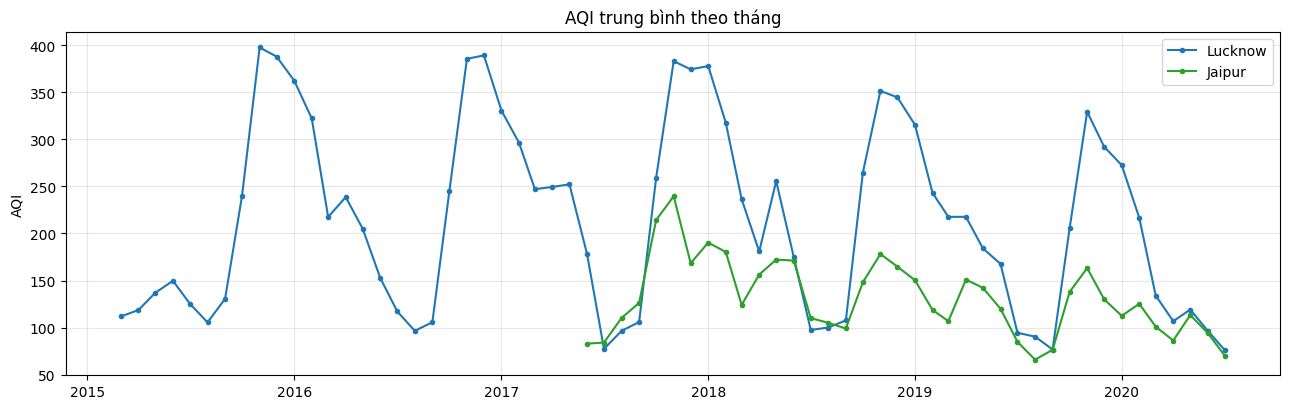

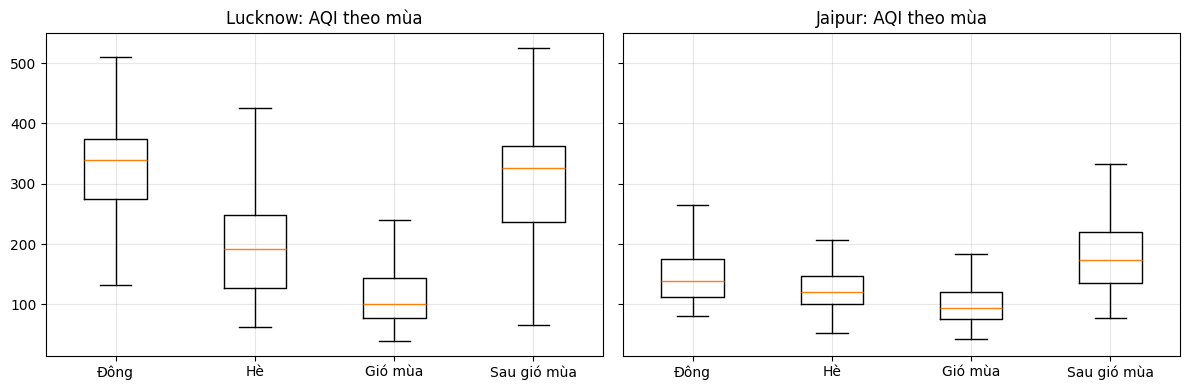

AQI trung vị theo mùa:


,Lucknow,Jaipur
Season,,
Đông,339.0,139.0
Hè (trước gió mùa),191.0,121.0
Gió mùa,100.0,94.0
Sau gió mùa,326.0,173.0


AQI 6 tháng đầu năm (chỉ so sánh công bằng khi số ngày ~181):
--- Lucknow


,mean,median,n_ngay
Year,,,
2015,133.0,120.0,98
2016,257.0,250.0,160
2017,260.0,268.0,178
2018,257.0,250.0,181
2019,224.0,208.0,181
2020,158.0,137.0,182


--- Jaipur


,mean,median,n_ngay
Year,,,
2017,83.0,85.0,11
2018,165.0,157.0,180
2019,132.0,121.0,181
2020,105.0,106.0,182


In [9]:
SEASON = {12: "Đông", 1: "Đông", 2: "Đông", 3: "Hè (trước gió mùa)", 4: "Hè (trước gió mùa)", 5: "Hè (trước gió mùa)",
          6: "Gió mùa", 7: "Gió mùa", 8: "Gió mùa", 9: "Gió mùa", 10: "Sau gió mùa", 11: "Sau gió mùa"}
ORDER = ["Đông", "Hè (trước gió mùa)", "Gió mùa", "Sau gió mùa"]
tr = {}
for c in CITIES:
    d = final[c].copy(); d["Year"] = d.Date.dt.year; d["Month"] = d.Date.dt.month; d["Season"] = d.Month.map(SEASON)
    tr[c] = d
    monthly = d.groupby([d.Date.dt.to_period("M")])[["PM2.5", "AQI"] + [x for x in ("PM10",) if x in d.columns]].agg("mean").round(1)
    monthly["n_ngay_AQI"] = d.groupby(d.Date.dt.to_period("M"))["AQI"].count()
    monthly.to_csv(INTERIM / f"{c.lower()}_monthly.csv")

# 8.1 chuỗi tháng của cả hai thành phố
fig, ax = plt.subplots(figsize=(13, 4.2))
for c, col in zip(CITIES, ["tab:blue", "tab:green"]):
    m = tr[c].set_index("Date")["AQI"].resample("MS").mean(); ax.plot(m.index, m.values, marker="o", ms=3, label=c, color=col)
ax.set_title("AQI trung bình theo tháng"); ax.set_ylabel("AQI"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG / "aqi_monthly_lucknow_jaipur.png", dpi=130); plt.show()

# 8.2 tính mùa
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, c in zip(axes, CITIES):
    d = tr[c]; data = [d.loc[d.Season == s, "AQI"].dropna() for s in ORDER]
    ax.boxplot(data, labels=[s.split(" (")[0] for s in ORDER], showfliers=False); ax.set_title(f"{c}: AQI theo mùa"); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG / "aqi_season_lucknow_jaipur.png", dpi=130); plt.show()
season_tbl = pd.DataFrame({c: tr[c].groupby("Season")["AQI"].median().reindex(ORDER) for c in CITIES}).round(0)
print("AQI trung vị theo mùa:"); display(season_tbl)

# 8.3 so sánh công bằng theo năm: chỉ lấy các tháng 1-6 (dữ liệu kết thúc 1/7/2020, và Jaipur bắt đầu 14/6/2017)
print("AQI 6 tháng đầu năm (chỉ so sánh công bằng khi số ngày ~181):")
for c in CITIES:
    h1 = tr[c][tr[c].Month <= 6]; print(f"--- {c}")
    display(h1.groupby("Year")["AQI"].agg(mean="mean", median="median", n_ngay="count").round(0))

In [10]:
# 8.4 Giả thuyết COVID-19 (phong tỏa từ 25/3/2020): so sánh Tháng 4-5 với Tháng 1-2 của cùng năm.
# Nếu 2020 là ngoại lệ (tỉ số thấp hơn hẳn các năm trước) thì giả thuyết phong tỏa được ủng hộ.
rows = []
for c in CITIES:
    d = tr[c]
    for y in sorted(d.Year.unique()):
        a = d[(d.Year == y) & d.Month.isin([1, 2])]["AQI"]; b = d[(d.Year == y) & d.Month.isin([4, 5])]["AQI"]
        if a.count() >= 45 and b.count() >= 55:
            rows.append(dict(city=c, nam=y, AQI_thang_1_2=round(a.mean()), AQI_thang_4_5=round(b.mean()), ti_so_4_5_tren_1_2=round(b.mean() / a.mean(), 2)))
covid = pd.DataFrame(rows).set_index(["city", "nam"]); display(covid)

AQI_thang_1_2  AQI_thang_4_5  ti_so_4_5_tren_1_2
city    nam                                                   
Lucknow 2017            314            251                0.80
        2018            349            219                0.63
        2019            281            201                0.71
        2020            246            113                0.46
Jaipur  2018            186            164                0.89
        2019            135            147                1.08
        2020            119            100                0.84

### Kết quả xu hướng theo thời gian (bản nháp)

1. **Tính mùa rất mạnh ở cả hai thành phố.** Trung vị AQI: Lucknow mùa đông 339, sau gió mùa 326, hè 191, gió mùa 100; Jaipur 139, 173, 121, 94. Đỉnh rơi vào tháng 10-12, đáy vào tháng 7-9. Lucknow cao và dao động mạnh hơn hẳn Jaipur.
2. **Xu hướng giảm đỉnh mùa đông.** So sánh công bằng bằng cách chỉ lấy tháng 11-12 (61 ngày mỗi năm, đủ dữ liệu, chưa bị ảnh hưởng bởi COVID): AQI trung bình Lucknow đi 393 -> 388 -> 379 -> 348 -> 310 (2015-2019), giảm ~21%; Jaipur 203 -> 171 -> 146 (2017-2019), giảm ~28%. PM2.5 tháng 11-12 giảm cùng chiều (Lucknow 244 -> 163; Jaipur 94 -> 62). Đây là mô tả, chưa phải kết luận nguyên nhân.
3. **Đừng so sánh trung bình cả năm.** Dữ liệu dừng 1/7/2020 và Jaipur chỉ bắt đầu 14/6/2017; Lucknow 2015 chỉ có 98 ngày trong 6 tháng đầu, Jaipur 2017 chỉ có 11 ngày. Bảng 6 tháng đầu năm là so sánh công bằng, không dùng hai năm thiếu này.
4. **Giả thuyết COVID-19 (phong tỏa từ 25/3/2020).** Tỉ số AQI tháng 4-5 trên tháng 1-2: Lucknow 0,80 (2017), 0,63 (2018), 0,71 (2019) và **0,46 (2020)**, thấp hơn mọi năm trước, ủng hộ giả thuyết. Jaipur 0,89 (2018), 1,08 (2019), 0,84 (2020) nằm trong dải các năm trước, **không thấy dấu hiệu riêng** của phong tỏa ở Jaipur. Chỉ có 3-4 năm để so sánh nên đây là gợi ý, không phải bằng chứng nhân quả.
5. **Hạn chế:** Jaipur chỉ có 3 năm; số 0 và các khối thiếu làm PM10, NH3, NOx, Benzene, CO không đủ để kết luận xu hướng; chưa có đối chiếu nguồn ngoài.

## 9. Cleaning log (EX4.4)

In [11]:
log_df = pd.DataFrame(LOG)
log_df.to_csv(REPORTS / "cleaning_log_lucknow_jaipur.csv", index=False, encoding="utf-8-sig")
display(log_df)
print("\nĐã lưu reports/cleaning_log_lucknow_jaipur.csv, các hình trong reports/figures/, và 6 file csv trong data/interim/")

,step,city,column,issue,action,n_affected,reason
0,3.x flatline,Lucknow,CO,"chuỗi số 0 liên tiếp >= 3 ngày (cảm biến treo,...",đổi thành NaN,5,nồng độ khí thật hiếm khi đứng ở đúng 0 nhiều ...
1,3.x flatline,Lucknow,Benzene,"chuỗi số 0 liên tiếp >= 3 ngày (cảm biến treo,...",đổi thành NaN,75,nồng độ khí thật hiếm khi đứng ở đúng 0 nhiều ...
2,3.x flatline,Lucknow,Toluene,"chuỗi số 0 liên tiếp >= 3 ngày (cảm biến treo,...",đổi thành NaN,72,nồng độ khí thật hiếm khi đứng ở đúng 0 nhiều ...
3,3.2 missing,Lucknow,PM10,thiếu 100% mọi năm,bỏ cột,2009,không có dữ liệu thật để phân tích hay nội suy
4,3.2 missing,Lucknow,Xylene,thiếu 100% mọi năm,bỏ cột,2009,không có dữ liệu thật để phân tích hay nội suy
5,3.3 impute,Lucknow,PM2.5,thiếu 102 ngày (sau flatline),"nội suy theo thời gian, khoảng <= 14 ngày",24,chuỗi thời gian liên tục; khoảng dài hơn giữ N...
6,3.3 impute,Lucknow,NO,thiếu 24 ngày (sau flatline),"nội suy theo thời gian, khoảng <= 14 ngày",24,chuỗi thời gian liên tục; khoảng dài hơn giữ N...
7,3.3 impute,Lucknow,NO2,thiếu 24 ngày (sau flatline),"nội suy theo thời gian, khoảng <= 14 ngày",24,chuỗi thời gian liên tục; khoảng dài hơn giữ N...
8,3.3 impute,Lucknow,NOx,thiếu 324 ngày (sau flatline),"nội suy theo thời gian, khoảng <= 14 ngày",48,chuỗi thời gian liên tục; khoảng dài hơn giữ N...
9,3.3 impute,Lucknow,NH3,thiếu 1004 ngày (sau flatline),"nội suy theo thời gian, khoảng <= 14 ngày",5,chuỗi thời gian liên tục; khoảng dài hơn giữ N...



Đã lưu reports/cleaning_log_lucknow_jaipur.csv, các hình trong reports/figures/, và 6 file csv trong data/interim/


## Ghi chú cho nhóm

**1. Lỗi trong `utils.impute_time_series` (file chung của nhóm), mình KHÔNG sửa file đó.** Hàm dùng `interpolate(method='time', limit=14)`. Trong pandas, `limit` nghĩa là điền tối đa 14 ô đầu của mỗi khoảng thiếu rồi dừng, chứ **không** bỏ qua khoảng dài hơn 14. Vì vậy 14 ngày đầu của mỗi khoảng thiếu dài vẫn bị điền bằng đường thẳng nối sang đầu bên kia, trái với chú thích của hàm ("gap dài hơn CHỦ Ý để nguyên NaN"). Mình đo trên dữ liệu thật: hàm này điền nhầm **168 ô ở Delhi** và **294 ô ở Gurugram** nằm trong các khoảng thiếu > 14 ngày (Lucknow: 182 ô, Jaipur: 42 ô nếu dùng hàm này). Phần Lucknow và Jaipur dùng `gap_utils.interpolate_short_gaps`, chỉ điền khoảng <= 14 ngày và giữ nguyên NaN cả khoảng dài. **Cần báo bạn Tuấn** để nhóm thống nhất cách sửa trước khi gộp số liệu.

**2. Quy ước thống nhất với nhóm:** ngưỡng nội suy 14 ngày, số 0 liên tục >= 3 ngày -> NaN, giữ cột `*_was_missing`, không điền AQI. Định dạng file `*_after_missing.csv` giống file của Delhi và Gurugram, nên `pd.concat` được.

**3. Cần nhóm thống nhất cách xử lý ngoại lai chung.** Phần này chỉ gắn cờ, và chỉ đặt NaN cho điểm nghi lỗi có bằng chứng. Nếu thành viên khác xóa ngoại lai theo IQR thì số liệu ghép lại sẽ không so sánh được.

**4. Khi ghép các thành phố:** cột PM10 của Lucknow không tồn tại (thiếu 100%), Xylene bị bỏ ở cả hai thành phố, NH3 của Lucknow chỉ dùng được từ cuối 2017.